# Tea Leaf Disease Classification — Vision Transformer

***Fine-tunes a pretrained ViT (`vit_base_patch16_224`) on the "Identifying Disease in Tea Leaves" dataset.***

# Importing Tea leafs Dataset from kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/identifying-disease-in-tea-leafs")

print("Path to dataset files:", path)

100%|██████████| 740M/740M [00:35<00:00, 22.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")

/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1 -> 0 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset -> 0 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset/algal leaf -> 113 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset/brown blight -> 113 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset/white spot -> 142 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset/Anthracnose -> 100 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset/healthy -> 74 files
/root/.cache/kagglehub/datasets/shashwatwork/identifying-disease-in-tea-leafs/versions/1/tea sickness dataset/

In [3]:
from sklearn.model_selection import train_test_split
import os
import shutil

source_dir = os.path.join(
    path,
    "tea sickness dataset"
)

output_dir_tea = "/content/tea_dataset"

classes_tea = [
    "red leaf spot",
    "brown blight",
    "gray light",
    "bird eye spot",
    "white spot",
    "algal leaf",
    "healthy",
    "Anthracnose"
]

# Create folders
for split in ["train", "val", "test"]:
    for class_name in classes_tea:
        os.makedirs(
            os.path.join(
                output_dir_tea,
                split,
                class_name
            ),
            exist_ok=True
        )

# Split each class
for class_name in classes_tea:

    class_dir = os.path.join(
        source_dir,
        class_name
    )

    files = [
        f for f in os.listdir(class_dir)
        if os.path.isfile(
            os.path.join(class_dir, f)
        )
    ]

    # 70% train, 30% temporary
    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=42
    )

    # 15% validation, 15% test
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42
    )

    # Copy train
    for filename in train_files:
        shutil.copy(
            os.path.join(class_dir, filename),
            os.path.join(
                output_dir_tea,
                "train",
                class_name,
                filename
            )
        )

    # Copy validation
    for filename in val_files:
        shutil.copy(
            os.path.join(class_dir, filename),
            os.path.join(
                output_dir_tea,
                "val",
                class_name,
                filename
            )
        )

    # Copy test
    for filename in test_files:
        shutil.copy(
            os.path.join(class_dir, filename),
            os.path.join(
                output_dir_tea,
                "test",
                class_name,
                filename
            )
        )

print("Tea dataset split completed!")

Tea dataset split completed!


In [4]:
for split in ["train", "val", "test"]:

    print("\n" + split.upper())

    for class_name in classes_tea:

        folder = os.path.join(
            output_dir_tea,
            split,
            class_name
        )

        count = len(os.listdir(folder))

        print(
            f"{class_name:18} -> {count}"
        )


TRAIN
red leaf spot      -> 100
brown blight       -> 79
gray light         -> 70
bird eye spot      -> 70
white spot         -> 99
algal leaf         -> 79
healthy            -> 51
Anthracnose        -> 70

VAL
red leaf spot      -> 21
brown blight       -> 17
gray light         -> 15
bird eye spot      -> 15
white spot         -> 21
algal leaf         -> 17
healthy            -> 11
Anthracnose        -> 15

TEST
red leaf spot      -> 22
brown blight       -> 17
gray light         -> 15
bird eye spot      -> 15
white spot         -> 22
algal leaf         -> 17
healthy            -> 12
Anthracnose        -> 15


In [5]:
from torchvision import transforms

tea_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [6]:
from torchvision import datasets

tea_train_dataset = datasets.ImageFolder(
    os.path.join(output_dir_tea, "train"),
    transform=tea_transform
)

tea_val_dataset = datasets.ImageFolder(
    os.path.join(output_dir_tea, "val"),
    transform=tea_transform
)

tea_test_dataset = datasets.ImageFolder(
    os.path.join(output_dir_tea, "test"),
    transform=tea_transform
)

In [7]:
print("Classes:", tea_train_dataset.classes)
print("Class mapping:", tea_train_dataset.class_to_idx)

Classes: ['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']
Class mapping: {'Anthracnose': 0, 'algal leaf': 1, 'bird eye spot': 2, 'brown blight': 3, 'gray light': 4, 'healthy': 5, 'red leaf spot': 6, 'white spot': 7}


In [8]:
image, label = tea_train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", tea_train_dataset.classes[label])
print("Min:", image.min().item())
print("Max:", image.max().item())

Image shape: torch.Size([3, 224, 224])
Label: 0
Class: Anthracnose
Min: 0.01568627543747425
Max: 0.9098039269447327


In [9]:
from torch.utils.data import DataLoader

tea_batch_size = 16

tea_train_loader = DataLoader(
    tea_train_dataset,
    batch_size=tea_batch_size,
    shuffle=True
)

tea_val_loader = DataLoader(
    tea_val_dataset,
    batch_size=tea_batch_size,
    shuffle=False
)

tea_test_loader = DataLoader(
    tea_test_dataset,
    batch_size=tea_batch_size,
    shuffle=False
)

print("Train batches:", len(tea_train_loader))
print("Validation batches:", len(tea_val_loader))
print("Test batches:", len(tea_test_loader))

Train batches: 39
Validation batches: 9
Test batches: 9


In [10]:
images, labels = next(iter(tea_train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])


In [11]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [12]:
import timm

num_tea_classes = len(
    tea_train_dataset.classes
)

tea_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=num_tea_classes
)

tea_model = tea_model.to(device)

print("Number of classes:", num_tea_classes)
print("Classes:", tea_train_dataset.classes)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Number of classes: 8
Classes: ['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
tea_criterion = nn.CrossEntropyLoss()

tea_optimizer = torch.optim.AdamW(
    tea_model.parameters(),
    lr=1e-4,
    weight_decay=0.01
)

In [14]:
tea_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

In [15]:
tea_model.train()

images, labels = next(
    iter(tea_train_loader)
)

# Normalize RGB images
images = torch.stack([
    tea_normalize(img)
    for img in images
])

# Move to GPU
images = images.to(device)
labels = labels.to(device)

# Clear gradients
tea_optimizer.zero_grad()

# Forward pass
outputs = tea_model(images)

# Calculate loss
loss = tea_criterion(
    outputs,
    labels
)

# Backpropagation
loss.backward()

# Update weights
tea_optimizer.step()

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Loss:", loss.item())

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 8])
Loss: 2.2380406856536865


In [17]:
num_epochs = 10

best_tea_val_accuracy = 0.0

tea_train_losses = []
tea_val_losses = []

tea_train_accuracies = []
tea_val_accuracies = []

for epoch in range(num_epochs):

    # TRAINING

    tea_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tea_train_loader:

        # Normalize
        images = torch.stack([
            tea_normalize(img)
            for img in images
        ])

        # Move to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        tea_optimizer.zero_grad()

        # Forward pass
        outputs = tea_model(images)

        # Loss
        loss = tea_criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        tea_optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # VALIDATION

    tea_model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tea_val_loader:

            # Normalize
            images = torch.stack([
                tea_normalize(img)
                for img in images
            ])

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = tea_model(images)

            # Loss
            loss = tea_criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    val_loss = running_loss / total
    val_accuracy = correct / total


    # SAVE HISTORY

    tea_train_losses.append(train_loss)
    tea_val_losses.append(val_loss)

    tea_train_accuracies.append(
        train_accuracy
    )

    tea_val_accuracies.append(
        val_accuracy
    )


    # SAVE BEST MODEL

    if val_accuracy > best_tea_val_accuracy:

        best_tea_val_accuracy = val_accuracy

        torch.save(
            tea_model.state_dict(),
            "/content/best_tea_rgb_vit.pth"
        )

        print(" Best tea model saved!")


    # PRINT RESULTS

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy*100:.2f}%"
    )


print("\nTea RGB ViT training complete.")

print(
    f"Best Validation Accuracy: "
    f"{best_tea_val_accuracy*100:.2f}%"
)

 Best tea model saved!
Epoch [1/10] | Train Loss: 1.0302 | Train Acc: 54.85% | Val Loss: 0.7969 | Val Acc: 65.91%
 Best tea model saved!
Epoch [2/10] | Train Loss: 0.5157 | Train Acc: 79.94% | Val Loss: 0.6093 | Val Acc: 70.45%
 Best tea model saved!
Epoch [3/10] | Train Loss: 0.3569 | Train Acc: 85.11% | Val Loss: 0.5715 | Val Acc: 78.03%
Epoch [4/10] | Train Loss: 0.1939 | Train Acc: 93.20% | Val Loss: 0.9236 | Val Acc: 72.73%
 Best tea model saved!
Epoch [5/10] | Train Loss: 0.1895 | Train Acc: 92.56% | Val Loss: 0.6444 | Val Acc: 81.06%
 Best tea model saved!
Epoch [6/10] | Train Loss: 0.1227 | Train Acc: 95.95% | Val Loss: 0.6632 | Val Acc: 81.82%
Epoch [7/10] | Train Loss: 0.1919 | Train Acc: 95.15% | Val Loss: 0.8052 | Val Acc: 80.30%
Epoch [8/10] | Train Loss: 0.0119 | Train Acc: 99.68% | Val Loss: 1.1657 | Val Acc: 78.79%
Epoch [9/10] | Train Loss: 0.0538 | Train Acc: 98.38% | Val Loss: 0.7952 | Val Acc: 80.30%
Epoch [10/10] | Train Loss: 0.0807 | Train Acc: 97.25% | Val Loss:

In [18]:
tea_model.load_state_dict(
    torch.load(
        "/content/best_tea_rgb_vit.pth",
        map_location=device
    )
)

tea_model = tea_model.to(device)
tea_model.eval()

print("Best tea RGB model loaded.")

Best tea RGB model loaded.


In [19]:
tea_predictions = []
tea_test_labels = []

with torch.no_grad():

    for images, labels in tea_test_loader:

        # Normalize
        images = torch.stack([
            tea_normalize(img)
            for img in images
        ])

        images = images.to(device)

        # Prediction
        outputs = tea_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        tea_predictions.extend(
            predictions.cpu().numpy()
        )

        tea_test_labels.extend(
            labels.numpy()
        )

print("Predictions:", len(tea_predictions))
print("Actual labels:", len(tea_test_labels))

Predictions: 135
Actual labels: 135


In [20]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
tea_test_accuracy = accuracy_score(
    tea_test_labels,
    tea_predictions
)

print(
    f"Tea RGB ViT Test Accuracy: "
    f"{tea_test_accuracy * 100:.2f}%"
)

Tea RGB ViT Test Accuracy: 82.96%


In [21]:
tea_macro_f1 = f1_score(
    tea_test_labels,
    tea_predictions,
    average="macro"
)

print(
    f"Tea RGB ViT Macro F1: "
    f"{tea_macro_f1:.4f}"
)

Tea RGB ViT Macro F1: 0.8206


In [22]:
print(
    classification_report(
        tea_test_labels,
        tea_predictions,
        target_names=tea_test_dataset.classes,
        digits=4
    )
)

               precision    recall  f1-score   support

  Anthracnose     0.8333    0.6667    0.7407        15
   algal leaf     0.9333    0.8235    0.8750        17
bird eye spot     0.5417    0.8667    0.6667        15
 brown blight     0.8000    0.9412    0.8649        17
   gray light     0.7778    0.4667    0.5833        15
      healthy     1.0000    1.0000    1.0000        12
red leaf spot     0.9167    1.0000    0.9565        22
   white spot     0.9474    0.8182    0.8780        22

     accuracy                         0.8296       135
    macro avg     0.8438    0.8229    0.8206       135
 weighted avg     0.8501    0.8296    0.8281       135



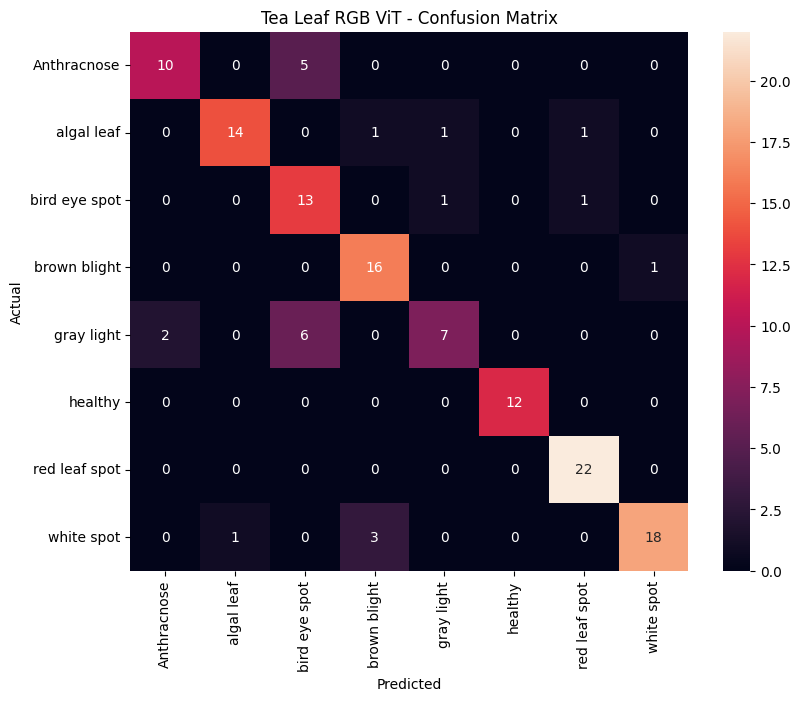

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    classification_report
)
cm_tea = confusion_matrix(
    tea_test_labels,
    tea_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_tea,
    annot=True,
    fmt="d",
    xticklabels=tea_test_dataset.classes,
    yticklabels=tea_test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tea Leaf RGB ViT - Confusion Matrix")

plt.show()

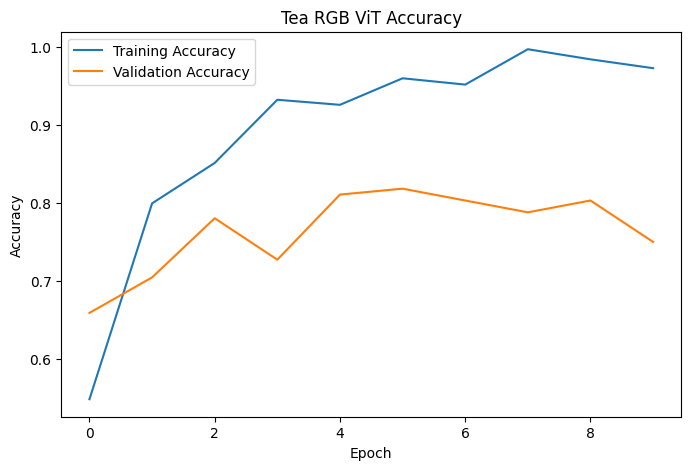

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    tea_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    tea_val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Tea RGB ViT Accuracy")

plt.legend()
plt.show()

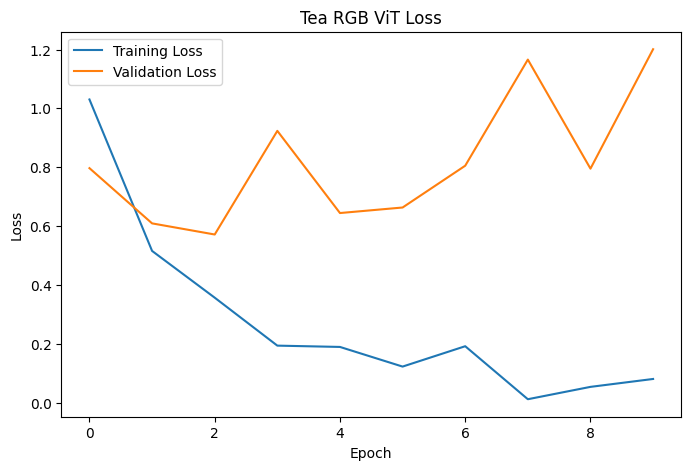

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    tea_train_losses,
    label="Training Loss"
)

plt.plot(
    tea_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tea RGB ViT Loss")

plt.legend()
plt.show()

In [26]:
torch.save(
    tea_model.state_dict(),
    "/content/final_tea_vit.pth"
)